## Segmentacion de datos 

Fuente: https://proyectos.inei.gob.pe/microdatos/?utm_source=chatgpt.com

- Encuesta: ENAHO Metodología ACTUALIZADA - Condiciones de Vida y Pobreza - ENAHO

- Módulos utilizados: 1,2,5,34

- Año: 2024 

- Periodo: Trimestre 1



#### PASO 1 : Consolidamos la data de los modulos en 1 solo dataset

In [1]:
#Recorremos la ruta principal para encontrar las rutas de los archivos .csv 
import os

ruta_general=r"C:\Users\Manuel\OneDrive\Desktop\Proyecto Python\Segmentacion"
Rutas_data_encontrado=[]
# os.walk recorre la carpeta principal, sus subcarpetas y las subcarpetas de estas...
for raiz, carpetas, archivos in os.walk(ruta_general):
    for nombre_archivo in archivos:
        # Verificamos si el archivo termina en .csv
        if (nombre_archivo.startswith("Enaho01") or nombre_archivo.startswith("Sumaria-2024.csv") ) and nombre_archivo.endswith(".csv"):
            # Construimos la ruta completa para poder abrirlo después
            ruta_completa = os.path.join(raiz, nombre_archivo)
            Rutas_data_encontrado.append(ruta_completa)

#Limpieza de rutas
Rutas_limpias = [ruta.replace("\\", "/") for ruta in Rutas_data_encontrado]
print(Rutas_limpias)

['C:/Users/Manuel/OneDrive/Desktop/Proyecto Python/Segmentacion/966-Modulo01/966-Modulo01/Enaho01-2024-100.csv', 'C:/Users/Manuel/OneDrive/Desktop/Proyecto Python/Segmentacion/966-Modulo02/966-Modulo02/Enaho01-2024-200.csv', 'C:/Users/Manuel/OneDrive/Desktop/Proyecto Python/Segmentacion/966-Modulo03/966-Modulo03/Enaho01A-2024-300.csv', 'C:/Users/Manuel/OneDrive/Desktop/Proyecto Python/Segmentacion/966-Modulo05/966-Modulo05/Enaho01a-2024-500.csv', 'C:/Users/Manuel/OneDrive/Desktop/Proyecto Python/Segmentacion/966-Modulo34/966-Modulo34/Sumaria-2024.csv']


In [2]:
#Cargamos todas los archivos de las rutas encontradas y creamos variables individuales, esto para poder diferencialas

import pandas as pd
import os

# Diccionario donde guardaremos los datasets
dataframes = {}

for ruta in Rutas_data_encontrado:
    
    nombre_archivo = os.path.basename(ruta).replace(".csv","")
    
    df = pd.read_csv(ruta, encoding="latin-1")
    
    dataframes[nombre_archivo] = df

print("Archivos cargados:")
print(dataframes.keys())

C:\Users\Manuel\AppData\Local\Temp\ipykernel_21320\244801272.py:13: DtypeWarning: Columns (24,30,44,330) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta, encoding="latin-1")
C:\Users\Manuel\AppData\Local\Temp\ipykernel_21320\244801272.py:13: DtypeWarning: Columns (218,223,228,236,241,246,251,256,336,338,341,344,347,350,353,356,359,363,365,367,369,371,373,375,377,379,381,385,386,387,388,389,393,498,499,500,501,948,949,950,951,952,953,954,955,956,957,1028,1031,1036) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta, encoding="latin-1")


Archivos cargados:
dict_keys(['Enaho01-2024-100', 'Enaho01-2024-200', 'Enaho01A-2024-300', 'Enaho01a-2024-500', 'Sumaria-2024'])


In [3]:
# Los datasets están cargados en diccionarios
dataframes.keys()

dict_keys(['Enaho01-2024-100', 'Enaho01-2024-200', 'Enaho01A-2024-300', 'Enaho01a-2024-500', 'Sumaria-2024'])

In [4]:
#Seleccionando columnas necesarias

df_personas=dataframes["Enaho01-2024-200"]
df_personas=df_personas[["CONGLOME", "VIVIENDA", "HOGAR","CODPERSO","P208A","P207","P209"]]

df_hogar=dataframes["Enaho01-2024-100"]
df_hogar=df_hogar[["CONGLOME", "VIVIENDA","ESTRATO", "HOGAR","P101"]]

df_empleo_ingreso=dataframes["Enaho01a-2024-500"]
df_empleo_ingreso=df_empleo_ingreso[["CONGLOME", "VIVIENDA", "HOGAR","CODPERSO","OCU500"]]

df_summary=dataframes["Sumaria-2024"]
df_summary=df_summary[["CONGLOME", "VIVIENDA", "HOGAR","INGHOG2D","GASHOG2D","MIEPERHO","POBREZA","ESTRSOCIAL"]]
df_summary["INGPC"]=(df_summary["INGHOG2D"] / 12) / df_summary["MIEPERHO"]   # ===> Calcula el ingreso percapita



C:\Users\Manuel\AppData\Local\Temp\ipykernel_21320\3009902330.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_summary["INGPC"]=(df_summary["INGHOG2D"] / 12) / df_summary["MIEPERHO"]   # ===> Calcula el ingreso percapita


In [5]:
#La data viene separada por mes, debemos tener la granularidad a nivel cliente

df_personas=df_personas.groupby(['CODPERSO','CONGLOME','VIVIENDA','HOGAR']).agg({
                                                 'P208A':lambda x:x.mode()[0],
                                                 'P207': lambda x:x.mode()[0],
                                                 'P209': lambda x:x.mode()[0]
}).reset_index()

df_hogar=df_hogar.groupby(["CONGLOME", "VIVIENDA", "HOGAR"]).agg({
                                                 'ESTRATO':lambda x:x.mode()[0],
                                                 "P101":lambda x:x.mode()[0]
}).reset_index()

df_empleo_ingreso=df_empleo_ingreso.groupby(['CONGLOME', 'VIVIENDA','HOGAR','CODPERSO']).agg({
                                                "OCU500":lambda x:x.mode()[0]
}).reset_index()


                                

In [6]:
#Cruzamos la data de personas con la de hogar
df_merge_hogar=df_personas.merge(
                           df_hogar,
                           on=["CONGLOME", "VIVIENDA", "HOGAR"],
                           how="left"
)

In [7]:
#Cruzamos la data de hogar actualizada con ingresos
df_merge_empleo_ingreso=df_merge_hogar.merge(
                                            df_empleo_ingreso,
                                            on=["CONGLOME", "VIVIENDA", "HOGAR","CODPERSO"],
                                            how="left"
)

In [8]:
#cruzamos la data de ingresos con summary
df_merge_sumary=df_merge_empleo_ingreso.merge(
                                            df_summary,
                                            on=["CONGLOME", "VIVIENDA", "HOGAR"],
                                            how="left"
)

In [9]:
#Creamos una copia de la data consolidada
df=df_merge_sumary.copy()

In [10]:
# Verificamos los campos
df.head()

,CODPERSO,CONGLOME,VIVIENDA,HOGAR,P208A,P207,P209,ESTRATO,P101,OCU500,INGHOG2D,GASHOG2D,MIEPERHO,POBREZA,ESTRSOCIAL,INGPC
0,1,10651,13,11,74,1,2,4,3,4.0,45736.128906,35921.207031,4,3,4,952.836019
1,1,10651,26,11,48,1,2,4,1,1.0,40958.332031,17307.408203,5,2,4,682.638867
2,1,10651,55,11,52,1,1,4,1,1.0,51856.000000,22795.812500,4,3,4,1080.333333
3,1,10651,69,11,48,1,1,4,1,1.0,39501.000000,25891.462891,2,3,4,1645.875000
4,1,10651,84,11,45,1,2,4,1,1.0,9110.000000,30620.609375,4,3,4,189.791667


#### Paso 2: Seleccionamos la data para la clusterización

In [11]:
columnas_cluster = [
    "P208A",        # Edad.                                                 Está en el Módulo 200.
    "P207",         # Sexo.                                                 Está en el Módulo 200.
    "P209",         # Estado civil                                          Está en el Módulo 200
    "OCU500",       #Condicion laboral
    "P101",         #Tipo de vivienda
    "INGHOG2D",      #Ingreso Neto Total
    "INGPC",         #Ingreso Percapita
    "GASHOG2D",      #Gasto bruto total
    "ESTRATO"   # Urbano / Rural
]

In [12]:
#Para una mejor apreciación , cambiamos el nombre de las columnas
df_cluster=df[columnas_cluster].rename(columns={'P208A':'Edad',
                                     'P207':'Sexo',
                                     'P209':'Estado Civil',
                                     'OCU500':'Condición laboral',
                                     'P101':'Tipo de vivienda',
                                     'INGHOG2D':'Ingreso Neto Total',
                                     'INGPC':'Ingreso Percapita',
                                     'GASHOG2D':'Gasto bruto total',  
                                     'ESTRATO':'Urbano/Rural'
                                       })

In [13]:
#Verificando valores nulos
df_cluster.isnull().sum()/df_cluster.isnull().count() *100

Edad                   0.00000
Sexo                   0.00000
Estado Civil           0.00000
Condición laboral     26.95271
Tipo de vivienda       0.00000
Ingreso Neto Total     0.00000
Ingreso Percapita      0.00000
Gasto bruto total      0.00000
Urbano/Rural           0.00000
dtype: float64

In [14]:
#Realizamos un rastreo para identificar espacios vacios tomados como texto
import numpy as np
# 1. Definimos las columnas numéricas que están dando problemas
cols_numericas = ['Edad', 'Ingreso Neto Total', 'Ingreso Percapita', 'Gasto bruto total']

# 2. Reemplazamos los espacios vacíos por NaN y convertimos a número
for col in cols_numericas:
    # errors='coerce' convertirá lo que no sea número (como el " ") en NaN automáticamente
    df_cluster[col] = pd.to_numeric(df_cluster[col], errors='coerce')

# 3. (Opcional) Llenar los vacíos con 0 si así lo requiere tu lógica de cluster
df_cluster[cols_numericas] = df_cluster[cols_numericas].fillna(0)


# Lista de tus variables categóricas
cols_categoricas = ['Sexo', 'Condición laboral', 'Tipo de vivienda', 'Urbano/Rural', 'Estado Civil']

for col in cols_categoricas:
    # 1. Convertimos todo a string y quitamos espacios accidentales
    df_cluster[col] = df_cluster[col].astype(str).str.strip()
    
    # 2. Reemplazamos el string vacío por NaN real de numpy
    df_cluster[col] = df_cluster[col].replace(['', 'nan', 'None'], np.nan)

In [15]:
#Verificando nuevamente los valores nulos
df_cluster.isnull().sum()/df_cluster.isnull().count() *100

Edad                   0.000000
Sexo                   3.368983
Estado Civil          21.015792
Condición laboral     26.952710
Tipo de vivienda       0.961596
Ingreso Neto Total     0.000000
Ingreso Percapita      0.000000
Gasto bruto total      0.000000
Urbano/Rural           0.000000
dtype: float64

In [16]:
#Se imputaron variables categóricas con la moda para preservar tamaño muestral y evitar pérdida de información en el proceso de segmentación
df_cluster['Condición laboral'] = df_cluster['Condición laboral'].fillna(df_cluster['Condición laboral'].mode()[0])
df_cluster['Sexo'] = df_cluster['Sexo'].fillna(df_cluster['Sexo'].mode()[0])
df_cluster['Estado Civil'] = df_cluster['Estado Civil'].fillna(df_cluster['Estado Civil'].mode()[0])
df_cluster['Tipo de vivienda'] = df_cluster['Tipo de vivienda'].fillna(df_cluster['Tipo de vivienda'].mode()[0])


In [17]:
# Verificamos que no haya valores nulos
df_cluster.isnull().sum()/df_cluster.isnull().count()*100

Edad                  0.0
Sexo                  0.0
Estado Civil          0.0
Condición laboral     0.0
Tipo de vivienda      0.0
Ingreso Neto Total    0.0
Ingreso Percapita     0.0
Gasto bruto total     0.0
Urbano/Rural          0.0
dtype: float64

In [18]:
#Aseguramos el tipo de dato de las variables
df_cluster = df_cluster.astype({
    'Edad': 'float',
    'Sexo': 'category',
    'Condición laboral':'category',
    'Tipo de vivienda':'category',
    'Ingreso Neto Total':'float',
    'Ingreso Percapita':'float',
    'Gasto bruto total':'float',
    'Urbano/Rural':'category'
})

In [19]:
#Creamos una copia de nuestros campos para luego ser interpretados en el perfilado de clusters
df_cluster["Edad_real"] = df_cluster["Edad"]
df_cluster["Ingreso Neto Total Real"] = df_cluster["Ingreso Neto Total"]
df_cluster["Ingreso Percapita Real"] = df_cluster["Ingreso Percapita"]
df_cluster["Gasto bruto total Real"] = df_cluster["Gasto bruto total"]


#### Paso 3: Realizamos el proceso de clusterización

* 3.1 Escalamos las variables

#### Escalamiento para data numérica

In [20]:
#Realizamos un escalamiento a las variables numéricas
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_cluster["Edad"] = scaler.fit_transform(df_cluster[["Edad"]])
df_cluster["Ingreso Neto Total"] = scaler.fit_transform(df_cluster[["Ingreso Neto Total"]])
df_cluster["Ingreso Percapita"] = scaler.fit_transform(df_cluster[["Ingreso Percapita"]])
df_cluster["Gasto bruto total Real"] = scaler.fit_transform(df_cluster[["Gasto bruto total Real"]])


#### Escalamiento para data categórica

In [21]:
#Realizamos un escalamiento a las variables categóricas
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
# Aplicamos One-Hot Encoding a tus columnas categóricas ya limpias.
df_ready = pd.get_dummies(df_cluster, columns=['Sexo', 'Condición laboral', 'Tipo de vivienda', 'Urbano/Rural', 'Estado Civil'])
# Seleccionamos solo las columnas escaladas y los dummies (excluimos las "Real")
columnas_finales = [col for col in df_ready.columns if "Real" not in col]
X = df_ready[columnas_finales]

* 3.2 Identificamos el número de clusters 

K=2 calculado. Silueta (aprox): 0.6453
K=3 calculado. Silueta (aprox): 0.5849
K=4 calculado. Silueta (aprox): 0.5565
K=5 calculado. Silueta (aprox): 0.5547
K=6 calculado. Silueta (aprox): 0.5376
K=7 calculado. Silueta (aprox): 0.5340
K=8 calculado. Silueta (aprox): 0.5369


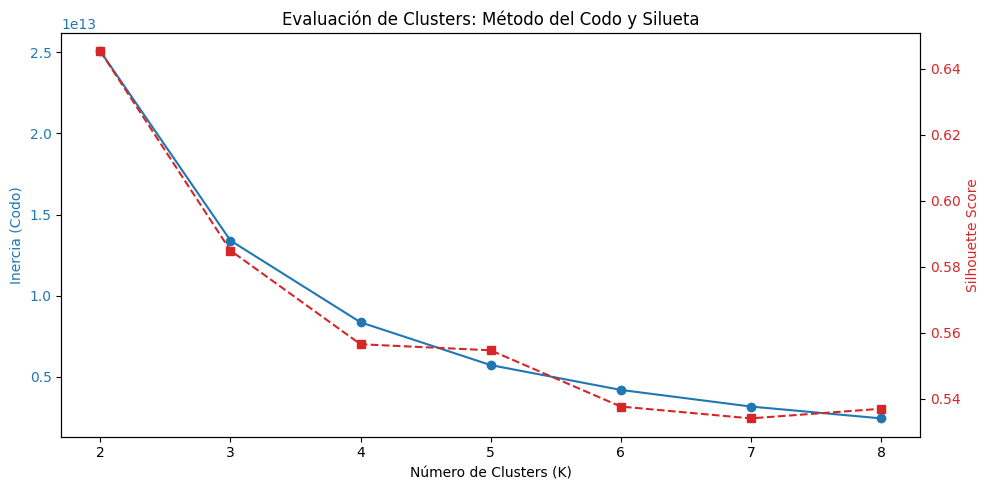

In [22]:
#Evaluamos con el método del codo y Silhouette para encontrar el número de cluster a utilizar

from sklearn.utils import resample # Importar esto
#CÁLCULO DE SILUETA Y CODO (ELBOW)
range_n_clusters = [2, 3, 4, 5, 6,7,8]
intercias = []
siluetas = []

for n_clusters in range_n_clusters:
    # Ajustamos el modelo
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    
    # 1. Guardamos Inercia
    intercias.append(kmeans.inertia_)

    # 2. Guardamos Silueta con MUESTREO (Optimización)
    # Si X es muy grande (>10k filas), tomamos una muestra
    limit_samples = 20000 
    
    if len(X) > limit_samples:
        # Muestreamos tanto X como las etiquetas generadas para que coincidan
        X_sample, labels_sample = resample(X, cluster_labels, 
                                           n_samples=limit_samples, 
                                           random_state=42)
        score = silhouette_score(X_sample, labels_sample)
    else:
        # Si es pequeño, usamos todo
        score = silhouette_score(X, cluster_labels)

    siluetas.append(score)
    print(f"K={n_clusters} calculado. Silueta (aprox): {score:.4f}")

# ==========================================
# 3. VISUALIZACIÓN DE RESULTADOS
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 5))

# Graficamos el Codo (Inercia)
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inercia (Codo)', color='tab:blue')
ax1.plot(range_n_clusters, intercias, 'o-', color='tab:blue', label="Inercia")
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Graficamos la Silueta en el mismo eje pero diferente escala
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(range_n_clusters, siluetas, 's--', color='tab:red', label="Silueta")
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Evaluación de Clusters: Método del Codo y Silueta')
fig.tight_layout()
plt.show()

- Hay un punto de quiebre en el 3er cluster , este será nuestro número de cluster ideal.

* 3.3 Aplicando KMeans

In [23]:
# 1. Configurar y entrenar el modelo final con 3 clusters
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)

# 2. Predecir los grupos usando tus datos preparados (X)
# Esto genera un array de 0s, 1s y 2s
cluster_labels = kmeans_final.fit_predict(X)

#Aplicar en el cluster
df_cluster['Cluster'] = cluster_labels

# Verificamos las primeras filas
df_cluster.head()

,Edad,Sexo,Estado Civil,Condición laboral,Tipo de vivienda,Ingreso Neto Total,Ingreso Percapita,Gasto bruto total,Urbano/Rural,Edad_real,Ingreso Neto Total Real,Ingreso Percapita Real,Gasto bruto total Real,Cluster
0,1.729087,1,2,4.0,3,0.068957,-0.023155,35921.207031,4,74.0,45736.128906,952.836019,0.101104,2
1,0.612891,1,2,1.0,1,-0.056170,-0.305225,17307.408203,4,48.0,40958.332031,682.638867,-0.695587,0
2,0.784614,1,1,1.0,1,0.229232,0.109945,22795.812500,4,52.0,51856.000000,1080.333333,-0.460678,0
3,0.612891,1,1,1.0,1,-0.094336,0.700337,25891.462891,4,48.0,39501.000000,1645.875000,-0.328180,0
4,0.484100,1,2,1.0,1,-0.890253,-0.819729,30620.609375,4,45.0,9110.000000,189.791667,-0.125768,0


In [24]:
#Reemplazamos el valor que corresponde a los codigos 

map_sexo = {
    1: "Hombre",
    2: "Mujer"
}
map_estrato={
    1: "De 500 000 a más habitantes",
    2: "De 100 000 a 499 999 habitantes",
    3: "De 50 000 a 99 999 habitantes",
    4: "De 20 000 a 49 999 habitantes",
    5: "De 2 000 a 19 999 habitantes",
    6: "De 500 a 1 999 habitantes",
    7: "Área de Empadronamiento Rural (AER) Compuesto",
    8: "Área de Empadronamiento Rural (AER) Simple",
}

map_estado_civil={
    1: "Conviviente",
    2: "Casado(a)",
    3: "Viudo(a)",
    4: "Divorciado(a)",
    5: "Separado(a)",
    6: "Soltero(a)"
}


map_condicion_laboral={
    1: "Indicador de la PEA"}

map_Tipo_de_vivienda={
    1:"Casa independiente",
    2:"Departamento en edificio",
    3:"Vivienda en quinta",
    4:"Vivienda en casa de vecindad (Callejón, solar o corralón)",
    5:"Choza o cabaña",
    6:"Vivienda improvisada",
    7:"Local no destinado para habitación humana",
    8:"Otro"
}

def limpiar_y_mapear(columna, mapa):
    return (
        pd.to_numeric(columna.astype(str).str.strip(), errors="coerce")
        .map(mapa)
        .astype("category")
    )

df_cluster["Sexo"] = limpiar_y_mapear(df_cluster["Sexo"], map_sexo)
df_cluster["Urbano/Rural"] = limpiar_y_mapear(df_cluster["Urbano/Rural"], map_estrato)
df_cluster["Estado Civil"] = limpiar_y_mapear(df_cluster["Estado Civil"], map_estado_civil)
df_cluster["Tipo de vivienda"] = limpiar_y_mapear(df_cluster["Tipo de vivienda"], map_Tipo_de_vivienda)
df_cluster["Condición laboral"] = limpiar_y_mapear(df_cluster["Condición laboral"], map_condicion_laboral)
 



In [25]:
#Verificamos en la data
df_cluster.head()

,Edad,Sexo,Estado Civil,Condición laboral,Tipo de vivienda,Ingreso Neto Total,Ingreso Percapita,Gasto bruto total,Urbano/Rural,Edad_real,Ingreso Neto Total Real,Ingreso Percapita Real,Gasto bruto total Real,Cluster
0,1.729087,Hombre,Casado(a),NaN,Vivienda en quinta,0.068957,-0.023155,35921.207031,De 20 000 a 49 999 habitantes,74.0,45736.128906,952.836019,0.101104,2
1,0.612891,Hombre,Casado(a),Indicador de la PEA,Casa independiente,-0.056170,-0.305225,17307.408203,De 20 000 a 49 999 habitantes,48.0,40958.332031,682.638867,-0.695587,0
2,0.784614,Hombre,Conviviente,Indicador de la PEA,Casa independiente,0.229232,0.109945,22795.812500,De 20 000 a 49 999 habitantes,52.0,51856.000000,1080.333333,-0.460678,0
3,0.612891,Hombre,Conviviente,Indicador de la PEA,Casa independiente,-0.094336,0.700337,25891.462891,De 20 000 a 49 999 habitantes,48.0,39501.000000,1645.875000,-0.328180,0
4,0.484100,Hombre,Casado(a),Indicador de la PEA,Casa independiente,-0.890253,-0.819729,30620.609375,De 20 000 a 49 999 habitantes,45.0,9110.000000,189.791667,-0.125768,0


#### 4. Perfilado de data

In [27]:
#PERFILADO NUMÉRICO

df_cluster.groupby("Cluster")["Edad_real"].agg(["mean","median","min","max"])



,mean,median,min,max
Cluster,,,,
0,34.518563,32.0,0.0,98.0
1,34.550787,32.0,0.0,98.0
2,32.084466,29.0,0.0,98.0


In [28]:
# Con este código se puede apreciar todo los margenes de las tablas
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)



In [31]:
#PERFILADO CATEGÓRICO
from IPython.display import display

for col in df_cluster.select_dtypes(include=["category","object"]).columns:
    
    print(f"\nVariable: {col}")
    
    tabla = pd.crosstab(
        df_cluster["Cluster"],
        df_cluster[col],
        normalize="index"
    )
    
    display(tabla)




Variable: Sexo


Sexo,Hombre,Mujer
Cluster,,
0,0.464367,0.535633
1,0.479939,0.520061
2,0.474266,0.525734



Variable: Estado Civil


Estado Civil,Casado(a),Conviviente,Divorciado(a),Separado(a),Soltero(a),Viudo(a)
Cluster,,,,,,
0,0.178703,0.201551,0.003969,0.087479,0.473807,0.054490
1,0.246572,0.129507,0.011300,0.061706,0.516506,0.034408
2,0.182863,0.180373,0.005526,0.073986,0.524048,0.033205



Variable: Condición laboral


Condición laboral,Indicador de la PEA
Cluster,
0,1.0
1,1.0
2,1.0



Variable: Tipo de vivienda


Tipo de vivienda,Casa independiente,Choza o cabaña,Departamento en edificio,Local no destinado para habitación humana,"Vivienda en casa de vecindad (Callejón, solar o corralón)",Vivienda en quinta,Vivienda improvisada
Cluster,,,,,,,
0,0.929871,0.014166,0.018093,0.000000,0.031726,0.005905,0.000238
1,0.845607,0.000000,0.142966,0.000000,0.004698,0.006729,0.000000
2,0.906636,0.001271,0.063401,0.000104,0.020183,0.008224,0.000182



Variable: Urbano/Rural


Urbano/Rural,De 100 000 a 499 999 habitantes,De 2 000 a 19 999 habitantes,De 20 000 a 49 999 habitantes,De 50 000 a 99 999 habitantes,De 500 000 a más habitantes,De 500 a 1 999 habitantes,Área de Empadronamiento Rural (AER) Compuesto,Área de Empadronamiento Rural (AER) Simple
Cluster,,,,,,,,
0,0.140890,0.141170,0.073243,0.065276,0.110397,0.070396,0.279998,0.118631
1,0.358558,0.073007,0.058151,0.098781,0.369223,0.009777,0.018029,0.014474
2,0.270157,0.127789,0.091367,0.103922,0.253658,0.028717,0.089447,0.034943


In [32]:
# Analizamos la proporcion de los clusters 
df_cluster["Cluster"].value_counts(normalize=True) * 100


0    60.564385
2    32.745220
1     6.690395
Name: Cluster, dtype: float64

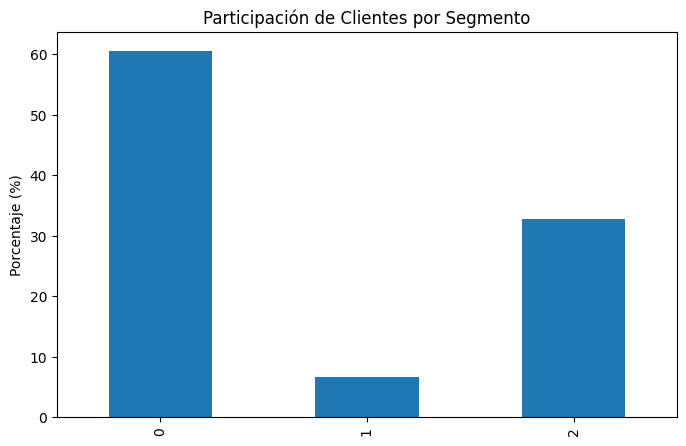

In [33]:
cluster_pct = df_cluster["Cluster"].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
cluster_pct.sort_index().plot(kind="bar")
plt.ylabel("Porcentaje (%)")
plt.title("Participación de Clientes por Segmento")
plt.show()


In [41]:
# Comparamos las medias de los 3 grupos
resumen = df_cluster2.groupby('Cluster').mean(numeric_only=True)

# Añadimos el conteo para tener contexto
resumen['Cantidad'] = df_cluster2['Cluster'].value_counts()

resumen


,Edad,Ingreso Neto Total,Ingreso Percapita,Gasto bruto total,Edad_real,Ingreso Neto Total Real,Ingreso Percapita Real,Gasto bruto total Real,Cantidad
Cluster,,,,,,,,,
0,0.034125,-0.468086,-0.302860,19606.062741,34.518563,25229.881701,684.905068,-0.597202,71297
1,0.035509,2.118874,1.403645,95619.257429,34.550787,124009.408383,2319.578816,2.656245,7876
2,-0.070372,0.432833,0.273370,46686.008151,32.084466,59630.249470,1236.879682,0.561849,38548


#### Resumen del perfilamiento

- Cluster 1
    * Nombre sugerido: VIP / Elite
    * Ingreso Neto Real: ~124,000 U.M.
    * Son pocos (7,876), pero su ingreso es casi 5 veces mayor que el del grupo base. Son tus clientes de más alto valor.
    * Vivienda Vertical: Es el grupo con mayor presencia en departamentos en edificios (14.3%), lo que sugiere un estilo de vida más cosmopolita o en zonas de alta plusvalía.
    * Ubicación: Viven principalmente en grandes ciudades. El 36.9% reside en urbes de más de 500,000 habitantes y el 35.8% en ciudades de 100,000 a 499,999 habitantes.
    * Estado Civil: Es el segmento con más casados (24.6%), lo que suele correlacionar con hogares de doble ingreso y mayor estabilidad económica.

- Cluster 2
    * Nombre sugerido: Clase Media / Potenciales 
    * Ingreso Neto Real: ~59,630 U.M.
    * Un grupo sólido (33%) con ingresos y gastos moderados. Es tu segmento de crecimiento.
    * Vivienda: Gran predominancia de casa independiente (90.6%).
    * Ubicación: Tienen una distribución equilibrada en ciudades medianas y grandes (25% en urbes de +500k habitantes).
    * Perfil: Es un grupo joven (promedio 32 años), mayoritariamente soltero (52.4%), que representa la fuerza laboral activa con ingresos medios.


- Cluster 0
    * Nombre sugerido: Masivo / Low-End
    * Ingreso Neto Real: ~25,229 U.M.
    * Es la gran mayoría (60%). Tienen el menor poder adquisitivo y probablemente son más sensibles al precio.
    * Entorno: Es el único grupo con una presencia significativa en Áreas de Empadronamiento Rural (sumando casi 40% entre AER Compuesto y Simple).
    * Vivienda: Casi todos viven en casas independientes (92.9%), con presencia de tipos de vivienda más sencillos como chozas o quintas.
    * Demografía: Tienen el mayor porcentaje de personas en unión libre o convivientes (20.1%).